In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [25]:
from google.colab import files
uploaded=files.upload()

Saving TCS1.csv to TCS1 (1).csv


In [26]:
df=pd.read_csv("TCS1.csv")
print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (4494, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-27,122.800003,122.800003,119.820000,120.332497,88.088272,30646000.0
1,2004-08-30,121.237503,123.750000,120.625000,123.345001,90.293549,24465208.0
2,2004-08-31,123.312500,123.750000,122.000000,123.512497,90.416122,21194656.0
3,2004-09-01,123.750000,124.375000,122.949997,123.487503,90.397820,19935544.0
4,2004-09-02,123.737503,125.574997,123.250000,124.207497,90.924896,21356352.0


In [27]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [42]:
df['Price_Next_Day']=df['Close'].shift(-1)
df['Price_Change']=df['Close']-df['Open']

In [29]:
df['return']=df['Close'].pct_change()
df=df.dropna()
df.head()

/tmp/ipython-input-3015031924.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return']=df['Close'].pct_change()


,Date,Open,High,Low,Close,Adj Close,Volume,Price_Next_Day,Price_Change,return
1,2004-08-30,121.237503,123.750000,120.625000,123.345001,90.293549,24465208.0,123.512497,2.107498,0.025035
2,2004-08-31,123.312500,123.750000,122.000000,123.512497,90.416122,21194656.0,123.487503,0.199997,0.001358
3,2004-09-01,123.750000,124.375000,122.949997,123.487503,90.397820,19935544.0,124.207497,-0.262497,-0.000202
4,2004-09-02,123.737503,125.574997,123.250000,124.207497,90.924896,21356352.0,124.732498,0.469994,0.005831
5,2004-09-03,125.750000,137.500000,123.794998,124.732498,91.309212,9869856.0,124.357498,-1.017502,0.004227


In [30]:
type(df)

pandas.core.frame.DataFrame

In [31]:
#defining x value and y values for training and testing
x=df.drop(['Date','Price_Next_Day','Price_Change','return'],axis=1)
y=df['Price_Next_Day']

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4476 entries, 1 to 4492
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4476 non-null   datetime64[ns]
 1   Open            4476 non-null   float64       
 2   High            4476 non-null   float64       
 3   Low             4476 non-null   float64       
 4   Close           4476 non-null   float64       
 5   Adj Close       4476 non-null   float64       
 6   Volume          4476 non-null   float64       
 7   Price_Next_Day  4476 non-null   float64       
 8   Price_Change    4476 non-null   float64       
 9   return          4476 non-null   float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 384.7 KB


In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y)

In [34]:
print("Training set size:",x_train.shape)
print("Training set size:",x_test.shape)

Training set size: (3357, 6)
Training set size: (1119, 6)


In [35]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()



In [36]:
from sklearn import metrics

In [37]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [38]:
y_predict=model.predict(x_test)

In [39]:
#finding errors
mse=metrics.mean_squared_error(y_test,y_predict)
mae=metrics.mean_absolute_error(y_test,y_predict)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae)

Mean Squared Error: 581.8069810444026
Mean Absolute Error: 13.805875604235593


In [40]:
#predict future data from present data
latest_data=df.tail(1)[['Open','High','Low','Close','Adj Close','Volume']]
predicted_price=model.predict(latest_data)
print("Predicted Next day Closing price for TCS:",round(predicted_price[0],2))

Predicted Next day Closing price for TCS: 3138.94


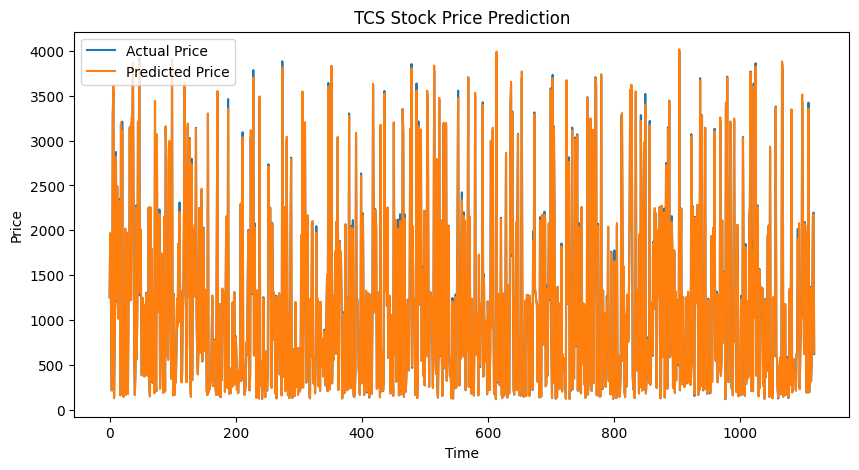

In [41]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values,label='Actual Price')
plt.plot(y_predict,label='Predicted Price')
plt.title('TCS Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()